In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# **Dice Roll**
Random Variables & Probability Distribution

In [2]:
rolls = np.random.randint(1,7, size = 10_000)
values, counts = np.unique(rolls, return_counts=True)
# values: Unique values as 1,2,3,4,5,6 
# counts: number of occurrences for each number

print("Values are: ",values)
print("-----------------------")
print("Counts are: ", counts)
print("-----------------------")
print("Length of rolls is: ", len(rolls))
prob = counts/len(rolls)
for v, p in zip(values, prob):
    print(f"value:{v} = {p:.3f}")

Values are:  [1 2 3 4 5 6]
-----------------------
Counts are:  [1713 1653 1662 1621 1680 1671]
-----------------------
Length of rolls is:  10000
value:1 = 0.171
value:2 = 0.165
value:3 = 0.166
value:4 = 0.162
value:5 = 0.168
value:6 = 0.167


In [3]:
print(f"Mean of rolls is:       {rolls.mean():.3f}")
print(f"Variance of rolls is:   {rolls.var():.3f}")

Mean of rolls is:       3.491
Variance of rolls is:   2.947


In [4]:
from scipy.stats import bernoulli, binom, norm

----------------Bernoulli----------------
----------------Binomi0al----------------
----------------Normal(Gaussian)----------------


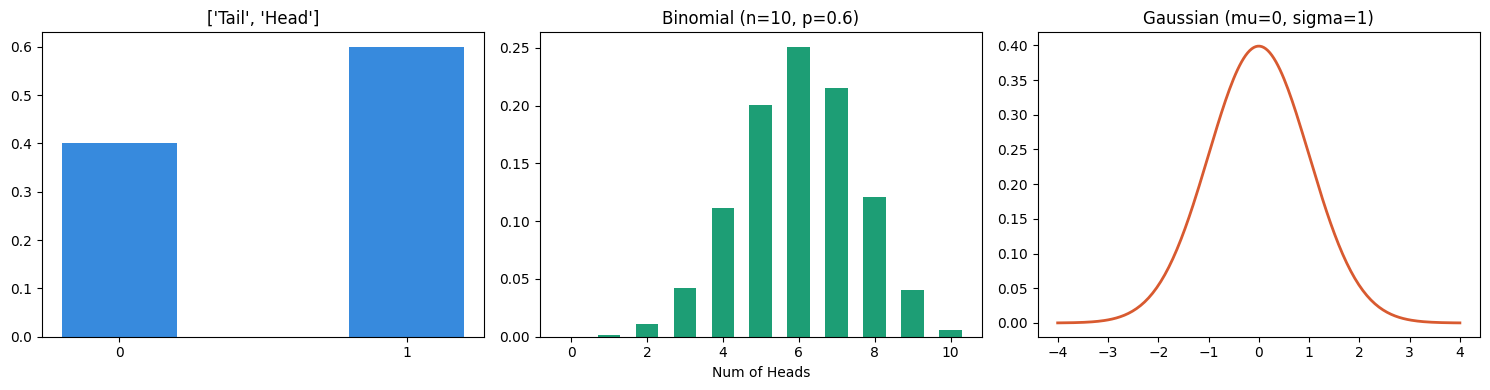

In [5]:
# Bernoulli حدث واحد له نتيجتين محتملتين
# القاء العملة مرة واحدة

print("----------------Bernoulli----------------")

fig, axis = plt.subplots(1,3, figsize=(15,4))
p = 0.6 # for Head
values = [0, 1]
axis[0].bar(values, bernoulli.pmf(values, p), color='#378ADD', width=0.4)
'''
PMF: Probability Mass Function (ايه احتمال ان ال هيد تطلع 6)
Bernoulli: p^x * (1-p)^1-x
for value:1 (0.6)^1 * (0.4)^1-1 -> 0.6
for value:0 (0.6)^0 * (0.4)^1-0 -> 0.4
'''
axis[0].set_title("Bernoulli (p=0.6)")
axis[0].set_xticks([0,1])
axis[0].set_title(['Tail', 'Head'])

print("----------------Binomi0al----------------")

n, p = 10, 0.6
values = np.arange(0, 11) # -> arr([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) عدد ظهور ال Head
axis[1].bar(values, binom.pmf(values, n, p), color='#1D9E75', width=0.6)
axis[1].set_title('Binomial (n=10, p=0.6)')
axis[1].set_xlabel('Num of Heads')

print("----------------Normal(Gaussian)----------------")

values = np.linspace(-4,4,200) # 200 values between -4 and 4
axis[2].plot(values, norm.pdf(values, 0, 1), color='#D85A30', linewidth=2) # plot curve 
axis[2].set_title("Gaussian (mu=0, sigma=1)")

plt.tight_layout()
plt.show()

In [6]:
# Binomial
n, p = 10, 0.6

# نظري
e_theoretical = n * p
var_theoretical = n * p * (1 - p)

# تجريبي — بنعمل simulation
samples = np.random.binomial(n, p, size=10_000)
e_empirical = samples.mean()
var_empirical = samples.var()

print(f"E(X)  — نظري: {e_theoretical:.3f} | تجريبي: {e_empirical:.3f}")
print(f"Var(X) — نظري: {var_theoretical:.3f} | تجريبي: {var_empirical:.3f}")

E(X)  — نظري: 6.000 | تجريبي: 6.008
Var(X) — نظري: 2.400 | تجريبي: 2.426


In [7]:
import numpy as np

# بيانات الطلاب
hours = np.array([1, 2, 3, 4, 5])
grades = np.array([50, 60, 70, 80, 90])

# Covariance matrix
cov_matrix = np.cov(hours, grades)
print("Covariance Matrix:")
print(cov_matrix)

# Covariance بس
cov = cov_matrix[0, 1]
print(f"\nCovariance(hours, grades) = {cov:.2f}")

# Correlation — نسخة normalized من الـ Covariance
corr = np.corrcoef(hours, grades)[0, 1]
print(f"Correlation = {corr:.2f}")

Covariance Matrix:
[[  2.5  25. ]
 [ 25.  250. ]]

Covariance(hours, grades) = 25.00
Correlation = 1.00


MLE estimate: p = 0.70


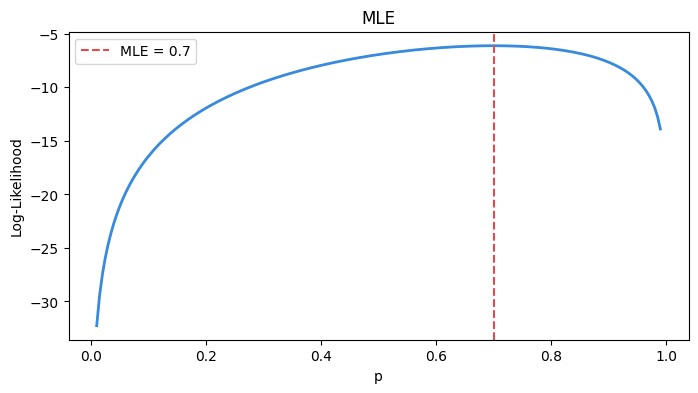

In [8]:
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# بياناتنا — 10 رميات طلع 7 heads
n_flips = 10
n_heads = 7

# Likelihood function
def likelihood(p):
    return (p ** n_heads) * ((1 - p) ** (n_flips - n_heads))

# Log-Likelihood — أستقر رياضياً
def log_likelihood(p):
    return n_heads * np.log(p) + (n_flips - n_heads) * np.log(1 - p)

# نجرب كل قيم p من 0 لـ 1
p_values = np.linspace(0.01, 0.99, 200)
ll_values = log_likelihood(p_values)

# MLE answer
p_mle = n_heads / n_flips
print(f"MLE estimate: p = {p_mle:.2f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(p_values, ll_values, color='#378ADD', linewidth=2)
plt.axvline(p_mle, color='#E24B4A', linestyle='--', label=f'MLE = {p_mle}')
plt.xlabel('p')
plt.ylabel('Log-Likelihood')
plt.title('MLE')
plt.legend()
plt.show()